In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
ecommerce_data = pd.read_csv('/Users/maheshg/Dropbox/Sample Datasets Kaggle/eCommerce_Product_Dataset/purchases.csv')

In [5]:
ecommerce_data_interactions = pd.read_csv('/Users/maheshg/Dropbox/Sample Datasets Kaggle/eCommerce_Product_Dataset/interactions.csv')

In [8]:
ecommerce_data_users = pd.read_csv('/Users/maheshg/Dropbox/Sample Datasets Kaggle/eCommerce_Product_Dataset/users.csv')

In [9]:
print(ecommerce_data_users.head())

                                user_id  age  gender country           city  \
0  8826d916-cdfb-41c6-81ff-91a761565a70   18  Female      US   Changchester   
1  2416da6e-c212-4ddb-8d88-00160eb686b2   32  Female      AU  New Tammyfort   
2  eb819333-b501-4c18-8c53-c786ed62c2f9   18    Male      US       Hullport   
3  71445abc-2f0d-4ac2-8097-acb7a3823bc9   58  Female      US  Howardborough   
4  13d16283-160e-4c20-aebd-f9d6297e4c73   38  Female      US    West Donald   

  signup_date income_level      preferred_category loyalty_tier  
0  2026-02-05       medium       Sports & Outdoors       bronze  
1  2025-03-03    very_high              Automotive       bronze  
2  2025-03-12       medium                   Books       bronze  
3  2025-09-21          low  Beauty & Personal Care       bronze  
4  2024-07-11       medium             Electronics       bronze  


In [10]:
ecommerce_data_users.size

90000

In [11]:
ecommerce_data_users.shape

(10000, 9)

In [13]:
ecommerce_data_users.columns

Index(['user_id', 'age', 'gender', 'country', 'city', 'signup_date',
       'income_level', 'preferred_category', 'loyalty_tier'],
      dtype='object')

In [14]:
ecommerce_data_users.ndim

2

Importing Additional libraries to preprocess the data

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

In [ ]:
# Prepare features (X) and labels (y)
# Combine product_id and user_id as text features; predict interaction_type
X = (ecommerce_data_interactions['product_id'].astype(str) + ' ' +
     ecommerce_data_interactions['user_id'].astype(str))
y = ecommerce_data_interactions['interaction_type'].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)

nlp_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1,2), stop_words='english')),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

    nlp_pipeline.fit(X_train, y_train)

    y_pred = nlp_pipeline.predict(X_test)

    print("Test accuracy:", accuracy_score(y_test, y_pred))
        print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification report:\n", classification_report(y_test, y_pred))

Test accuracy: 0.501325
Confusion matrix:
 [[    4     0    52     0     0  4688]
 [    5     1    30     0     0  4031]
 [    3     3    73     0     0  7914]
 [    2     0     9     0     0  1082]
 [    4     2    13     0     0  1899]
 [   15     4   191     0     0 19975]]


/Users/maheshg/Dropbox/git repos/PythonPractise/PythonPractise-1/study/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/maheshg/Dropbox/git repos/PythonPractise/PythonPractise-1/study/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Classification report:
                       precision    recall  f1-score   support

         add_to_cart       0.12      0.00      0.00      4744
     add_to_wishlist       0.10      0.00      0.00      4067
               click       0.20      0.01      0.02      7993
    remove_from_cart       0.00      0.00      0.00      1093
remove_from_wishlist       0.00      0.00      0.00      1918
                view       0.50      0.99      0.67     20185

            accuracy                           0.50     40000
           macro avg       0.15      0.17      0.11     40000
        weighted avg       0.32      0.50      0.34     40000



/Users/maheshg/Dropbox/git repos/PythonPractise/PythonPractise-1/study/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Confusion matrix (rows = actual / true, columns = predicted):


,add_to_cart,add_to_wishlist,click,remove_from_cart,remove_from_wishlist,view
add_to_cart,4,0,52,0,0,4688
add_to_wishlist,5,1,30,0,0,4031
click,3,3,73,0,0,7914
remove_from_cart,2,0,9,0,0,1082
remove_from_wishlist,4,2,13,0,0,1899
view,15,4,191,0,0,19975


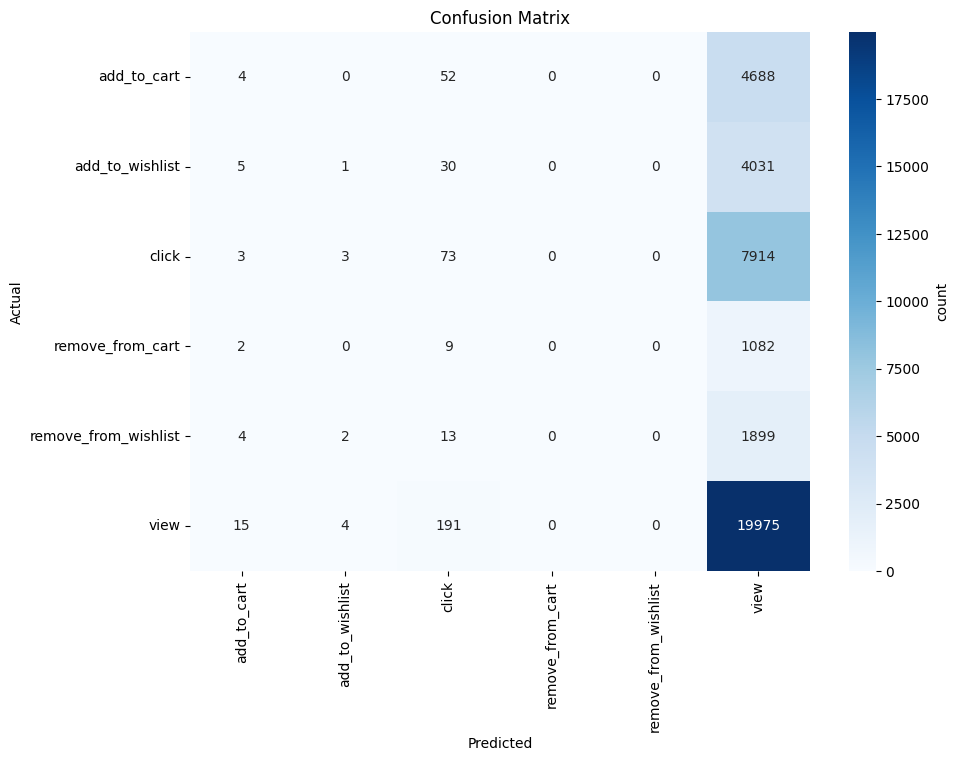

Overall accuracy: 0.5013

Per-class counts and metrics:
- add_to_cart: support=4744, TP=4, FP=29, FN=4740, precision=0.121, recall=0.001, f1=0.002
- add_to_wishlist: support=4067, TP=1, FP=9, FN=4066, precision=0.100, recall=0.000, f1=0.000
- click: support=7993, TP=73, FP=295, FN=7920, precision=0.198, recall=0.009, f1=0.017
- remove_from_cart: support=1093, TP=0, FP=0, FN=1093, precision=0.000, recall=0.000, f1=0.000
- remove_from_wishlist: support=1918, TP=0, FP=0, FN=1918, precision=0.000, recall=0.000, f1=0.000
- view: support=20185, TP=19975, FP=19614, FN=210, precision=0.505, recall=0.990, f1=0.668

Interpretation:
1) Diagonal cells (same actual and predicted) are correct predictions. Larger diagonal values => better per-class accuracy.
2) Off-diagonal cell [A,row -> B,col] counts how many actual A were predicted as B (model confusions).
3) Precision for a class = among predicted-as-class how many were correct (low precision => many false positives).
4) Recall for a class = amon

In [22]:
# Compute and display confusion matrix, per-class metrics, and a textual explanation.
labels = np.union1d(y_test.unique(), np.unique(y_pred))  # all labels present (sorted)
cm = confusion_matrix(y_test, y_pred, labels=labels)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

print("Confusion matrix (rows = actual / true, columns = predicted):")
display(cm_df)

# Plot heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'count'})
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

# Per-class metrics from the confusion matrix
total = cm.sum()
accuracy = np.trace(cm) / total if total else 0.0
print(f"Overall accuracy: {accuracy:.4f}\n")

print("Per-class counts and metrics:")
metrics_rows = []
for i, lbl in enumerate(labels):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP
    TN = total - TP - FP - FN
    support = TP + FN
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    metrics_rows.append((lbl, int(support), int(TP), int(FP), int(FN), precision, recall, f1))
    print(f"- {lbl}: support={support}, TP={TP}, FP={FP}, FN={FN}, precision={precision:.3f}, recall={recall:.3f}, f1={f1:.3f}")

# Textual interpretation / how to read the matrix
print("\nInterpretation:")
print("1) Diagonal cells (same actual and predicted) are correct predictions. Larger diagonal values => better per-class accuracy.")
print("2) Off-diagonal cell [A,row -> B,col] counts how many actual A were predicted as B (model confusions).")
print("3) Precision for a class = among predicted-as-class how many were correct (low precision => many false positives).")
print("4) Recall for a class = among actual-class how many were recovered (low recall => many false negatives).")
print("5) Use the matrix + per-class precision/recall to identify which classes the model confuses most (look for large off-diagonals and low recall/precision).")
print("6) If one class has very large support, consider class imbalance handling (resampling, class weights) or calibrating thresholds for better minority-class performance.")